# <center>HEART FAILURE DEATH PREDICTION<center>

**Nombre y apellidos: Pablo Sáez Gil**

In [79]:
# NO MODIFICAR NADA DEL CÓDIGO INCLUÍDO EN ESTA CELDA DEL CUADERNO

import numpy as np
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

seed_random = 173869890 # NO MODIFICAR LA SEMILLA ALEATORIA

uploaded = files.upload()

for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))

dataset = pd.read_csv('heart_failure_clinical_records_dataset.csv')

# NO MODIFICAR LA DIVISIÓN ENTRE TRAIN Y TEST
x_train, x_test, y_train, y_test = train_test_split(dataset.drop(columns=['DEATH_EVENT']), dataset['DEATH_EVENT'], test_size=0.2, random_state=seed_random)

# X son las variables de entrada
# Y es la variable de salida DEATH_EVENT
x_train.head()

# EJEMPLO, mitad de las predicciones 0 y mitad de las predicciones 1
y_example = np.concatenate([np.zeros(len(y_test) // 2), np.ones(len(y_test) - len(y_test) // 2)])
print(classification_report(y_test, y_example, digits=6)) # OJO: El valor de la fila accuracy y la columna f1-score es realmente el accuracy, está ahí por temas de formato de tabla. Accuracy no tiene "macro" ni "weighted" debido a que es un tipo de cálculo independiente. Ponderar accuracy no es estandar.

Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset (2).csv
User uploaded file "heart_failure_clinical_records_dataset (2).csv" with length 12239 bytes
              precision    recall  f1-score   support

           0   0.533333  0.470588  0.500000        34
           1   0.400000  0.461538  0.428571        26

    accuracy                       0.466667        60
   macro avg   0.466667  0.466063  0.464286        60
weighted avg   0.475556  0.466667  0.469048        60



# Preprocesado sobre Dataset

**Nombre y apellidos: Pablo Sáez Gil**

In [80]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [81]:
dataset.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [82]:
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

Número de outliers detectados por variable:


,Outliers,%_sobre_total
creatinine_phosphokinase,29.0,9.70
serum_creatinine,29.0,9.70
platelets,21.0,7.02
serum_sodium,4.0,1.34
ejection_fraction,2.0,0.67
diabetes,0.0,0.00
anaemia,0.0,0.00
age,0.0,0.00
high_blood_pressure,0.0,0.00
sex,0.0,0.00


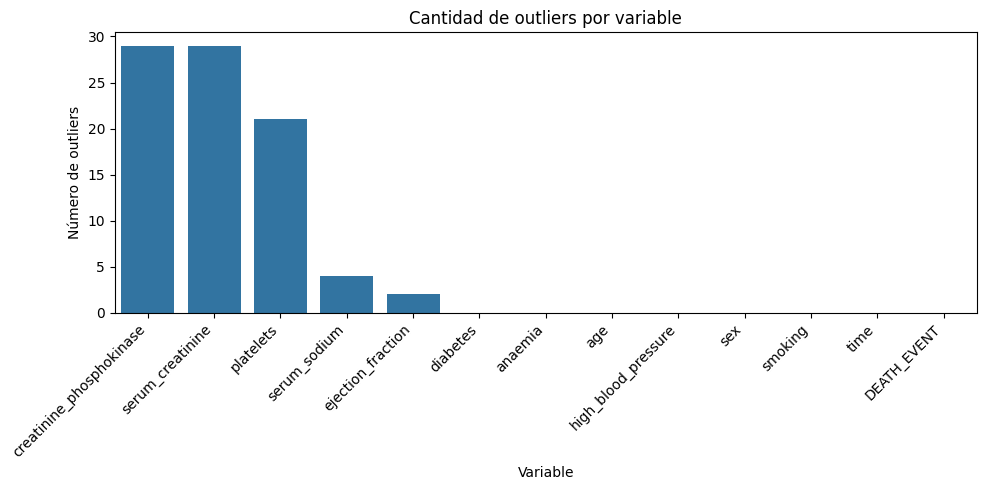

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

outlier_counts = {}
total_n = len(dataset)

for col in numeric_cols:
    series = dataset[col].dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (dataset[col] < lower) | (dataset[col] > upper)
    outlier_counts[col] = {
        'Outliers': int(mask.sum()),
        '%_sobre_total': round(100.0 * mask.sum() / total_n, 2)
    }

outlier_df = pd.DataFrame(outlier_counts).T.sort_values(by='Outliers', ascending=False)
print("Número de outliers detectados por variable:")
display(outlier_df)

# Gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=outlier_df.index, y=outlier_df['Outliers'])
plt.title("Cantidad de outliers por variable")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Número de outliers")
plt.xlabel("Variable")
plt.tight_layout()
plt.show()


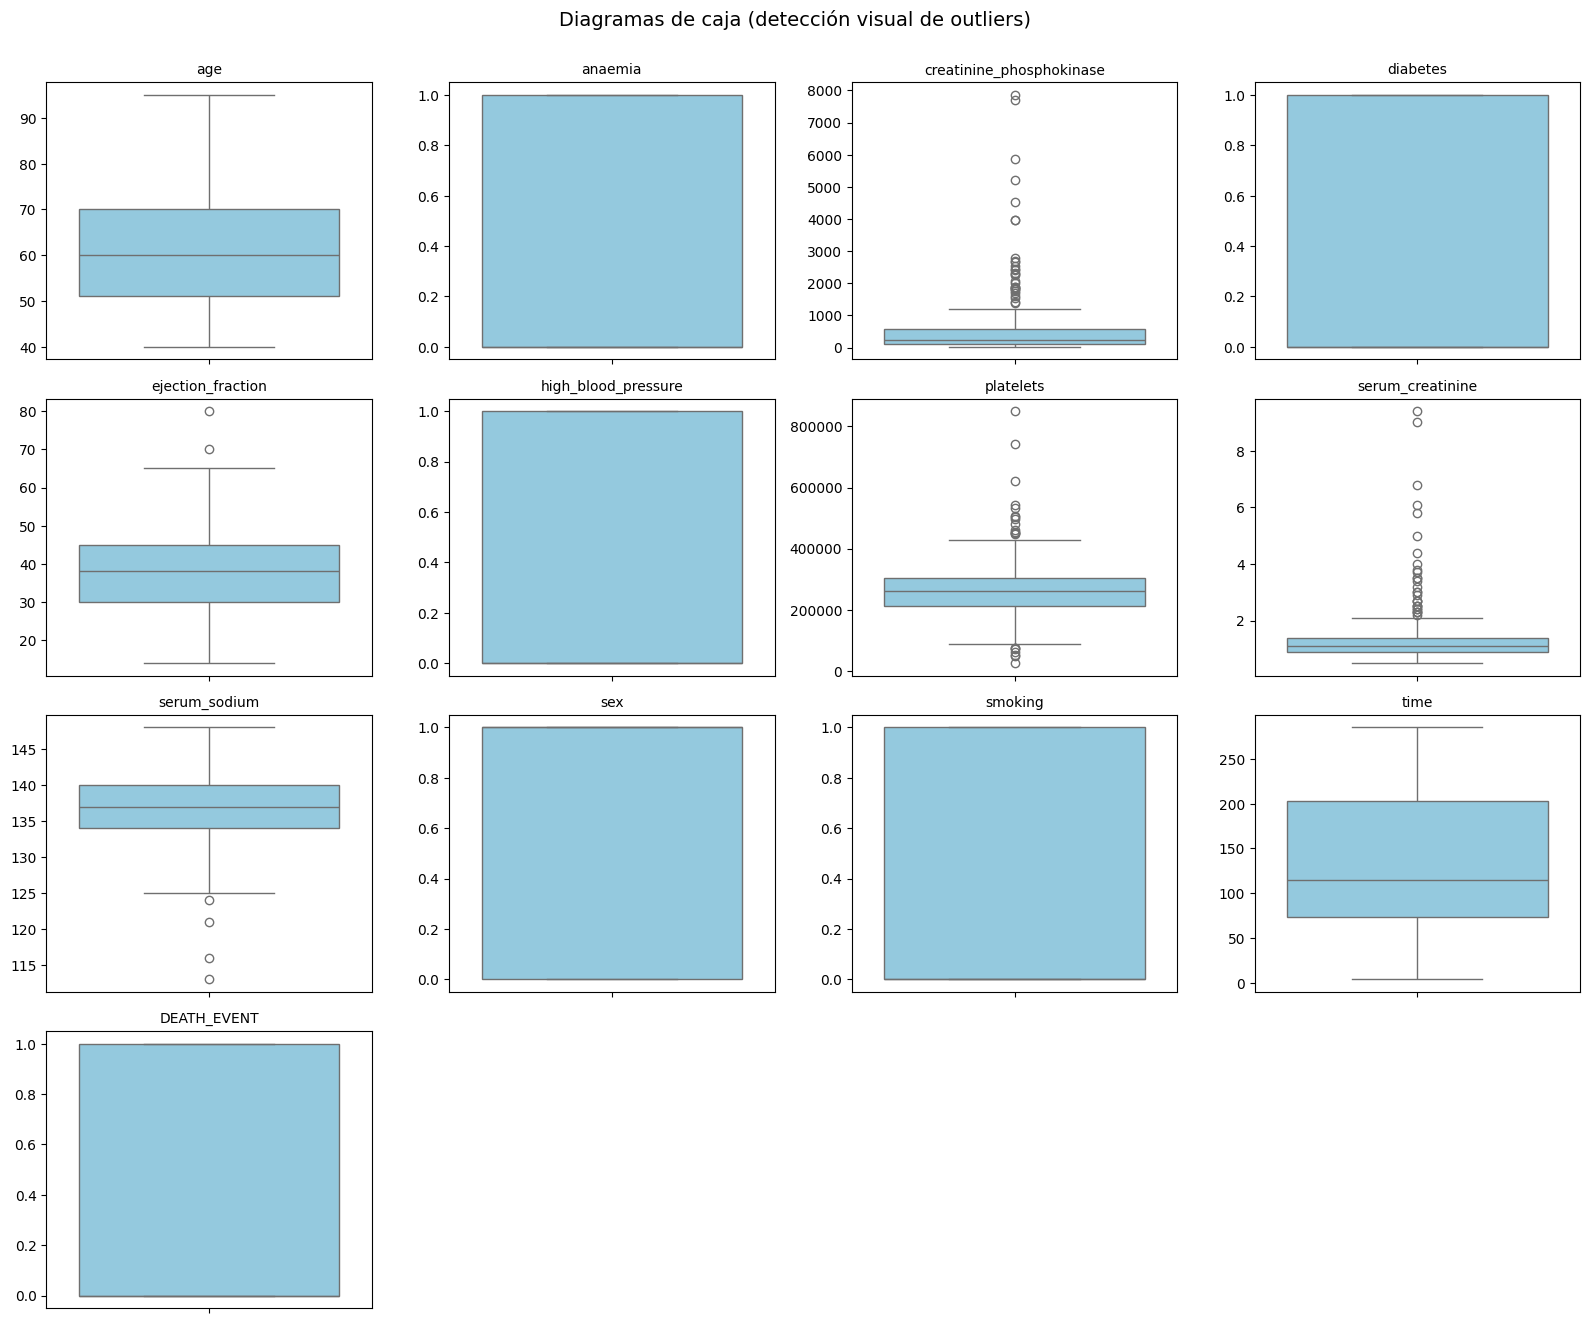

In [84]:
n = len(numeric_cols)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(4*cols, 3.2*rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=dataset[col], color='skyblue')
    plt.title(col, fontsize=10)
    plt.ylabel("")
plt.tight_layout()
plt.suptitle("Diagramas de caja (detección visual de outliers)", y=1.03, fontsize=14)
plt.show()


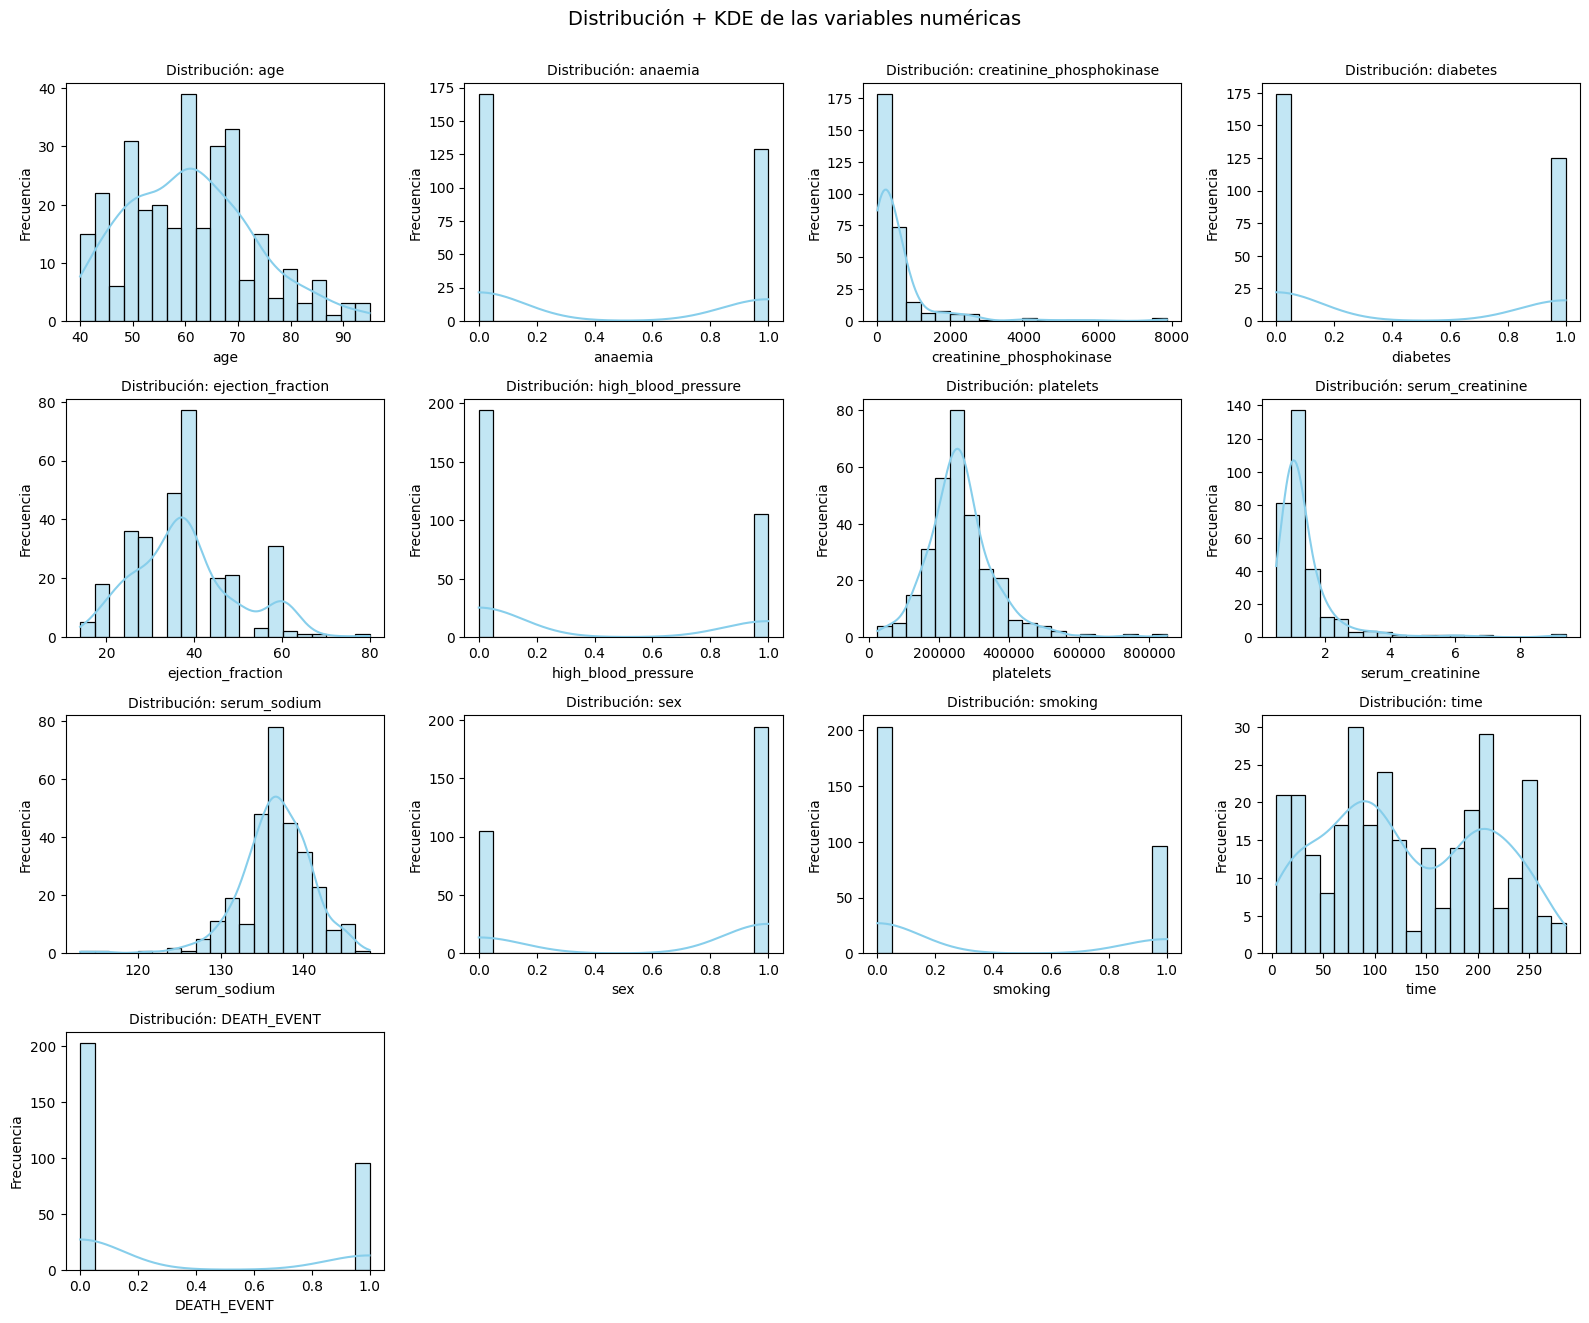

In [85]:
n = len(numeric_cols)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(4*cols, 3.2*rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(dataset[col], bins=20, kde=True, edgecolor='black', color='skyblue')
    plt.title(f"Distribución: {col}", fontsize=10)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
plt.tight_layout()
plt.suptitle("Distribución + KDE de las variables numéricas", y=1.03, fontsize=14)
plt.show()


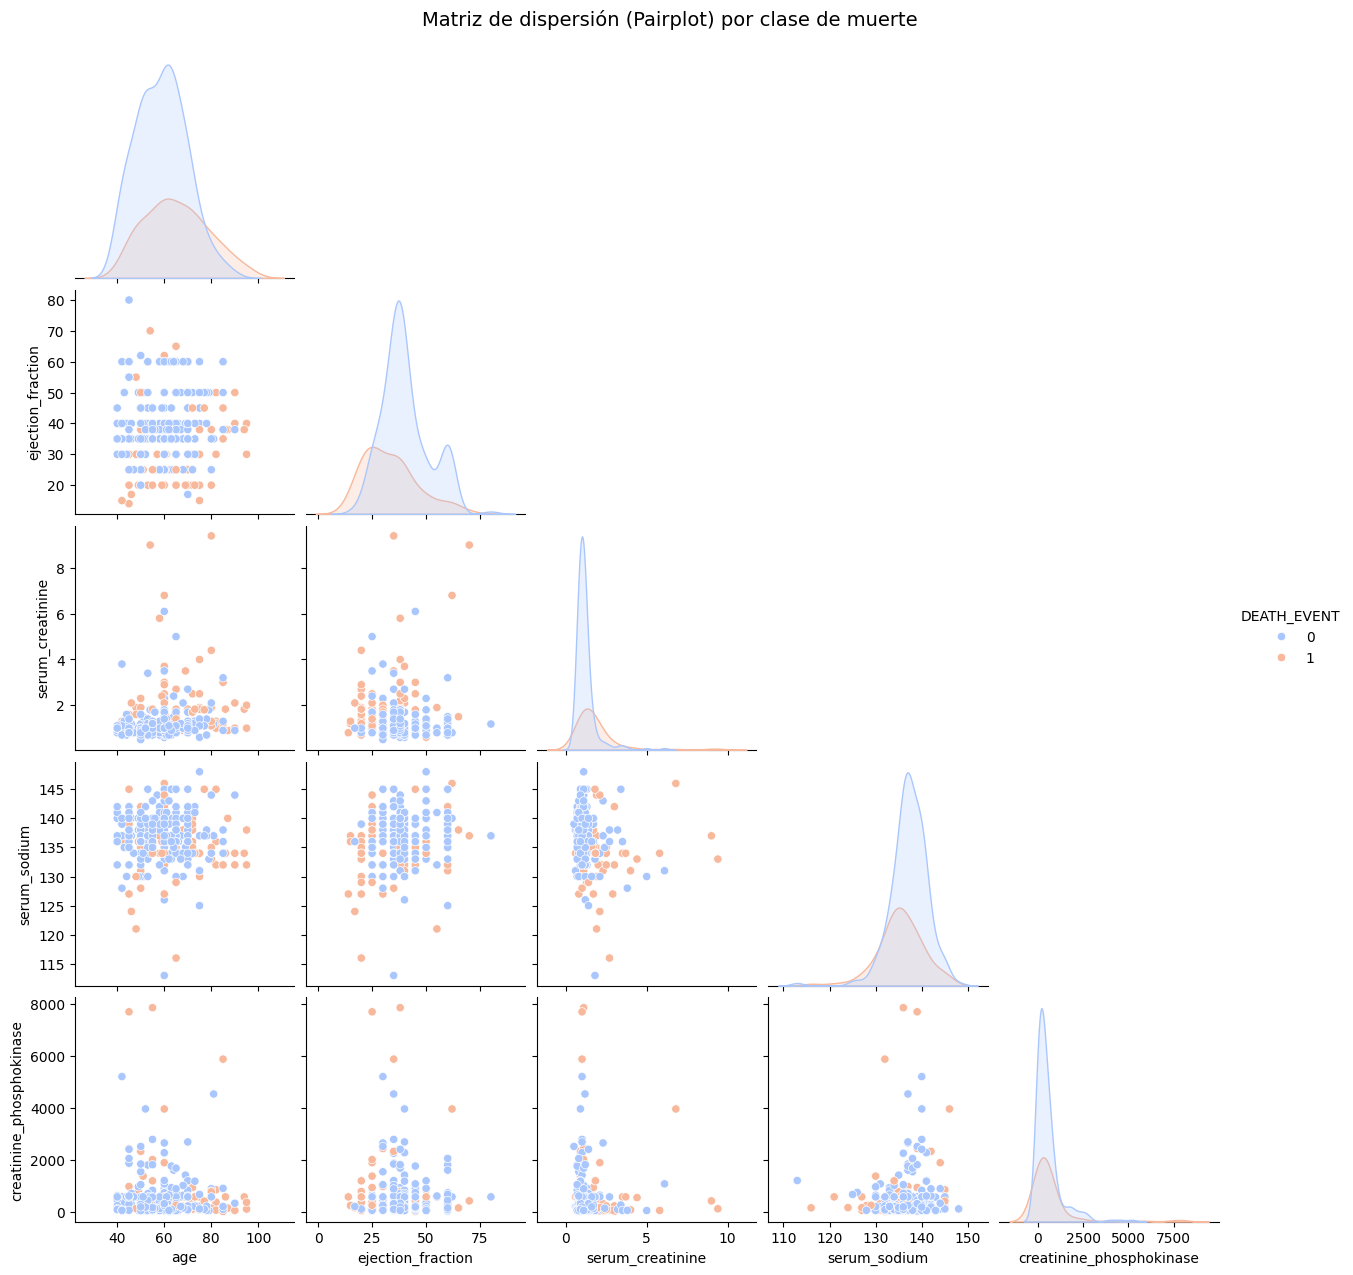

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos un subconjunto de variables relevantes para no saturar el gráfico
subset = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium','creatinine_phosphokinase', 'DEATH_EVENT']

sns.pairplot(dataset[subset], hue='DEATH_EVENT', palette='coolwarm', diag_kind='kde', corner=True)
plt.suptitle("Matriz de dispersión (Pairplot) por clase de muerte", y=1.02, fontsize=14)
plt.show()


# Preprocesado sobre Train-Test

In [87]:
numeric_cols = x_train.select_dtypes(include=['int64', 'float64']).columns

Número de outliers detectados por variable:


,Outliers,%_sobre_total
creatinine_phosphokinase,21.0,8.79
serum_creatinine,21.0,8.79
platelets,16.0,6.69
serum_sodium,6.0,2.51
age,2.0,0.84
ejection_fraction,2.0,0.84
diabetes,0.0,0.00
anaemia,0.0,0.00
high_blood_pressure,0.0,0.00
sex,0.0,0.00


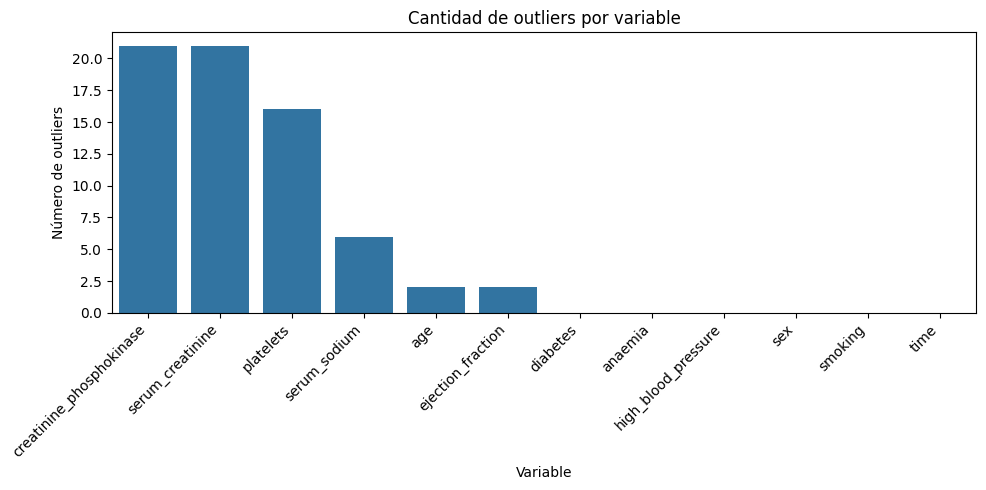

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

outlier_counts = {}
total_n = len(x_train)

for col in numeric_cols:
    series = x_train[col].dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (x_train[col] < lower) | (x_train[col] > upper)
    outlier_counts[col] = {
        'Outliers': int(mask.sum()),
        '%_sobre_total': round(100.0 * mask.sum() / total_n, 2)
    }

outlier_df = pd.DataFrame(outlier_counts).T.sort_values(by='Outliers', ascending=False)
print("Número de outliers detectados por variable:")
display(outlier_df)

# Gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=outlier_df.index, y=outlier_df['Outliers'])
plt.title("Cantidad de outliers por variable")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Número de outliers")
plt.xlabel("Variable")
plt.tight_layout()
plt.show()


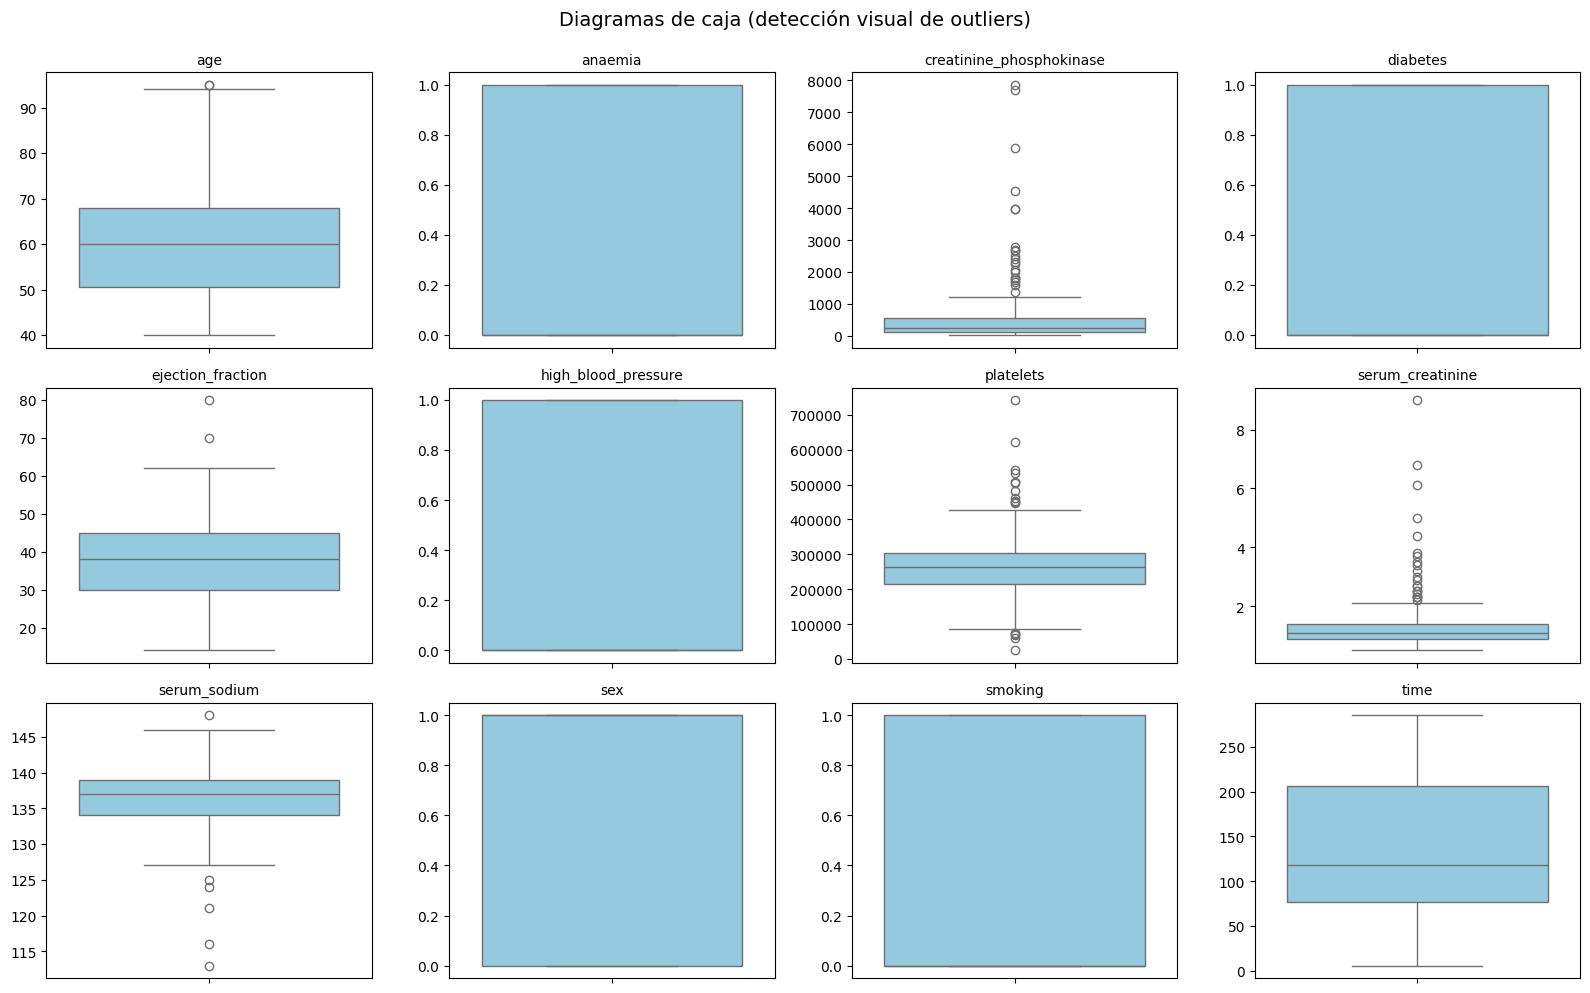

In [89]:
n = len(numeric_cols)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(4*cols, 3.2*rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=x_train[col], color='skyblue')
    plt.title(col, fontsize=10)
    plt.ylabel("")
plt.tight_layout()
plt.suptitle("Diagramas de caja (detección visual de outliers)", y=1.03, fontsize=14)
plt.show()


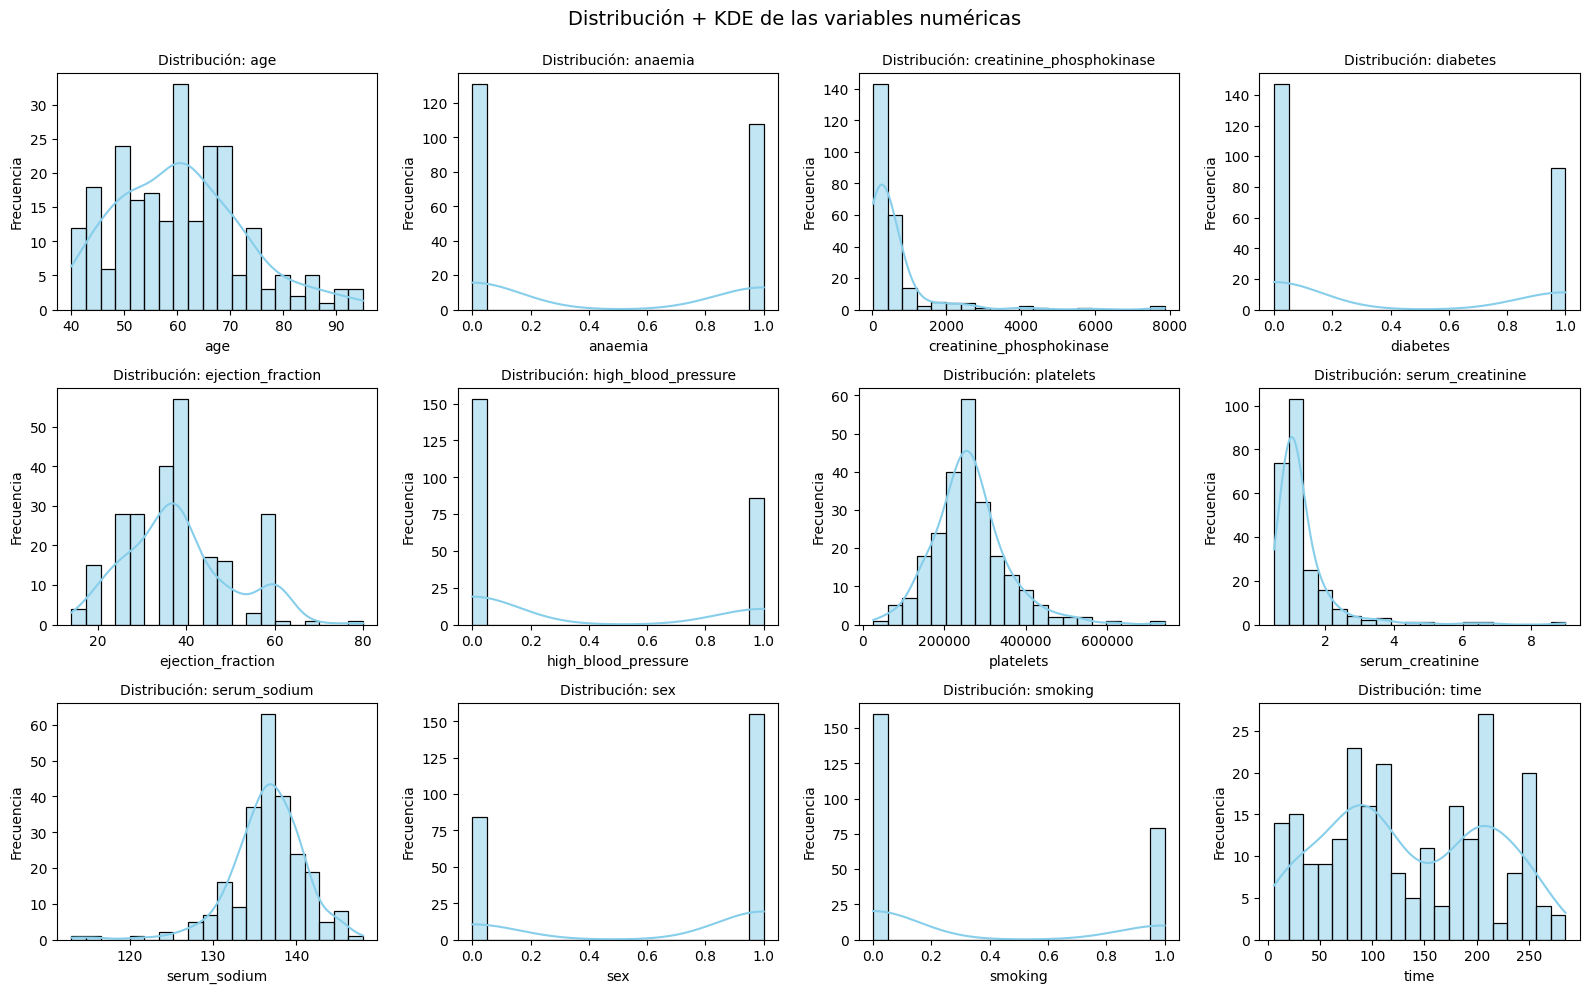

In [90]:
n = len(numeric_cols)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(4*cols, 3.2*rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(x_train[col], bins=20, kde=True, edgecolor='black', color='skyblue')
    plt.title(f"Distribución: {col}", fontsize=10)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
plt.tight_layout()
plt.suptitle("Distribución + KDE de las variables numéricas", y=1.03, fontsize=14)
plt.show()


# Transformaciones sobre Train-Test

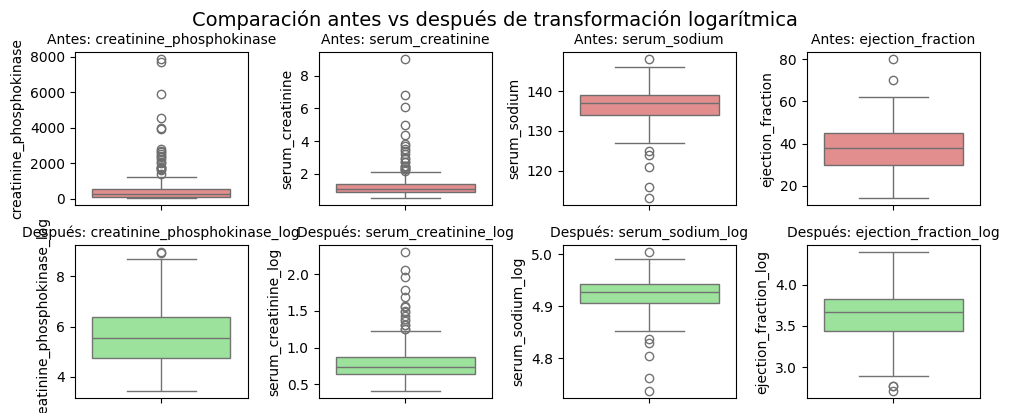

In [91]:
# Variables a transformar
vars_to_log = ['creatinine_phosphokinase', 'serum_creatinine', 'serum_sodium', 'ejection_fraction']

# Crear columnas transformadas (log1p evita problemas con ceros)
for col in vars_to_log:
    x_train[col + '_log'] = np.log1p(x_train[col])

# Visualización comparativa: antes vs después

cols = len(vars_to_log)
plt.figure(figsize=(10, 4))
for i, col in enumerate(vars_to_log, 1):
    plt.subplot(2, cols, i)
    sns.boxplot(y=x_train[col], color='lightcoral')
    plt.title(f"Antes: {col}", fontsize=10)

    plt.subplot(2, cols, i+cols)
    sns.boxplot(y=x_train[col + '_log'], color='lightgreen')
    plt.title(f"Después: {col}_log", fontsize=10)

plt.tight_layout()
plt.suptitle("Comparación antes vs después de transformación logarítmica", y=1.02, fontsize=14)
plt.show()


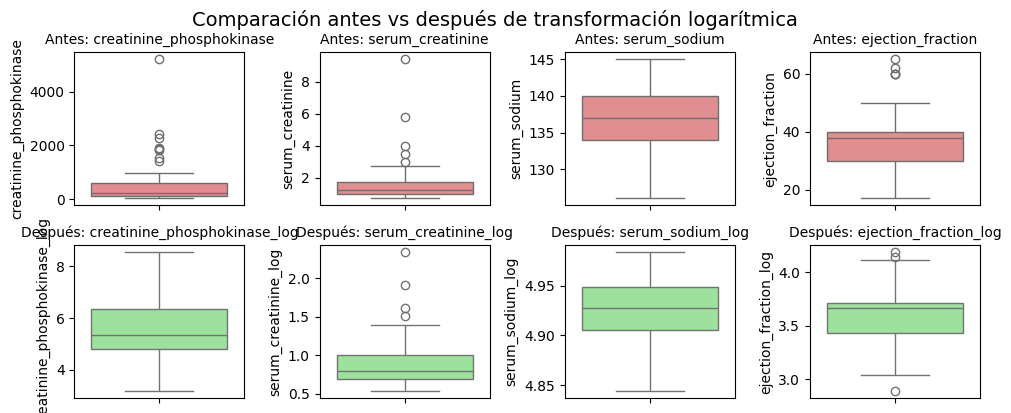

In [92]:
# Variables a transformar
vars_to_log = ['creatinine_phosphokinase', 'serum_creatinine', 'serum_sodium', 'ejection_fraction']

# Crear columnas transformadas (log1p evita problemas con ceros)
for col in vars_to_log:
    x_test[col + '_log'] = np.log1p(x_test[col])

# Visualización comparativa: antes vs después

cols = len(vars_to_log)
plt.figure(figsize=(10, 4))
for i, col in enumerate(vars_to_log, 1):
    plt.subplot(2, cols, i)
    sns.boxplot(y=x_test[col], color='lightcoral')
    plt.title(f"Antes: {col}", fontsize=10)

    plt.subplot(2, cols, i+cols)
    sns.boxplot(y=x_test[col + '_log'], color='lightgreen')
    plt.title(f"Después: {col}_log", fontsize=10)

plt.tight_layout()
plt.suptitle("Comparación antes vs después de transformación logarítmica", y=1.02, fontsize=14)
plt.show()


In [93]:
x_train_limpio = x_train.drop(["creatinine_phosphokinase", "serum_creatinine", 'serum_sodium', 'ejection_fraction'], axis=1).copy()
x_test_limpio = x_test.drop(["creatinine_phosphokinase", "serum_creatinine", 'serum_sodium', 'ejection_fraction'], axis=1).copy()
print(f"Información del conjunto de entrenamiento transformado: \n")
print(x_train_limpio.info())
print("\n")
print("Información del conjunto de test transformado: \n")
print(x_test_limpio.info())


Información del conjunto de entrenamiento transformado: 

<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 245 to 111
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           239 non-null    float64
 1   anaemia                       239 non-null    int64  
 2   diabetes                      239 non-null    int64  
 3   high_blood_pressure           239 non-null    int64  
 4   platelets                     239 non-null    float64
 5   sex                           239 non-null    int64  
 6   smoking                       239 non-null    int64  
 7   time                          239 non-null    int64  
 8   creatinine_phosphokinase_log  239 non-null    float64
 9   serum_creatinine_log          239 non-null    float64
 10  serum_sodium_log              239 non-null    float64
 11  ejection_fraction_log         239 non-null    float64
dtypes: float6

In [94]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

# Comparar outliers antes y después
for col in vars_to_log:
    before = count_outliers(x_train[col])
    after = count_outliers(x_train[col + '_log'])
    print(f"{col}: {before} → {after} outliers tras log-transform")


creatinine_phosphokinase: 21 → 2 outliers tras log-transform
serum_creatinine: 21 → 16 outliers tras log-transform
serum_sodium: 6 → 6 outliers tras log-transform
ejection_fraction: 2 → 3 outliers tras log-transform


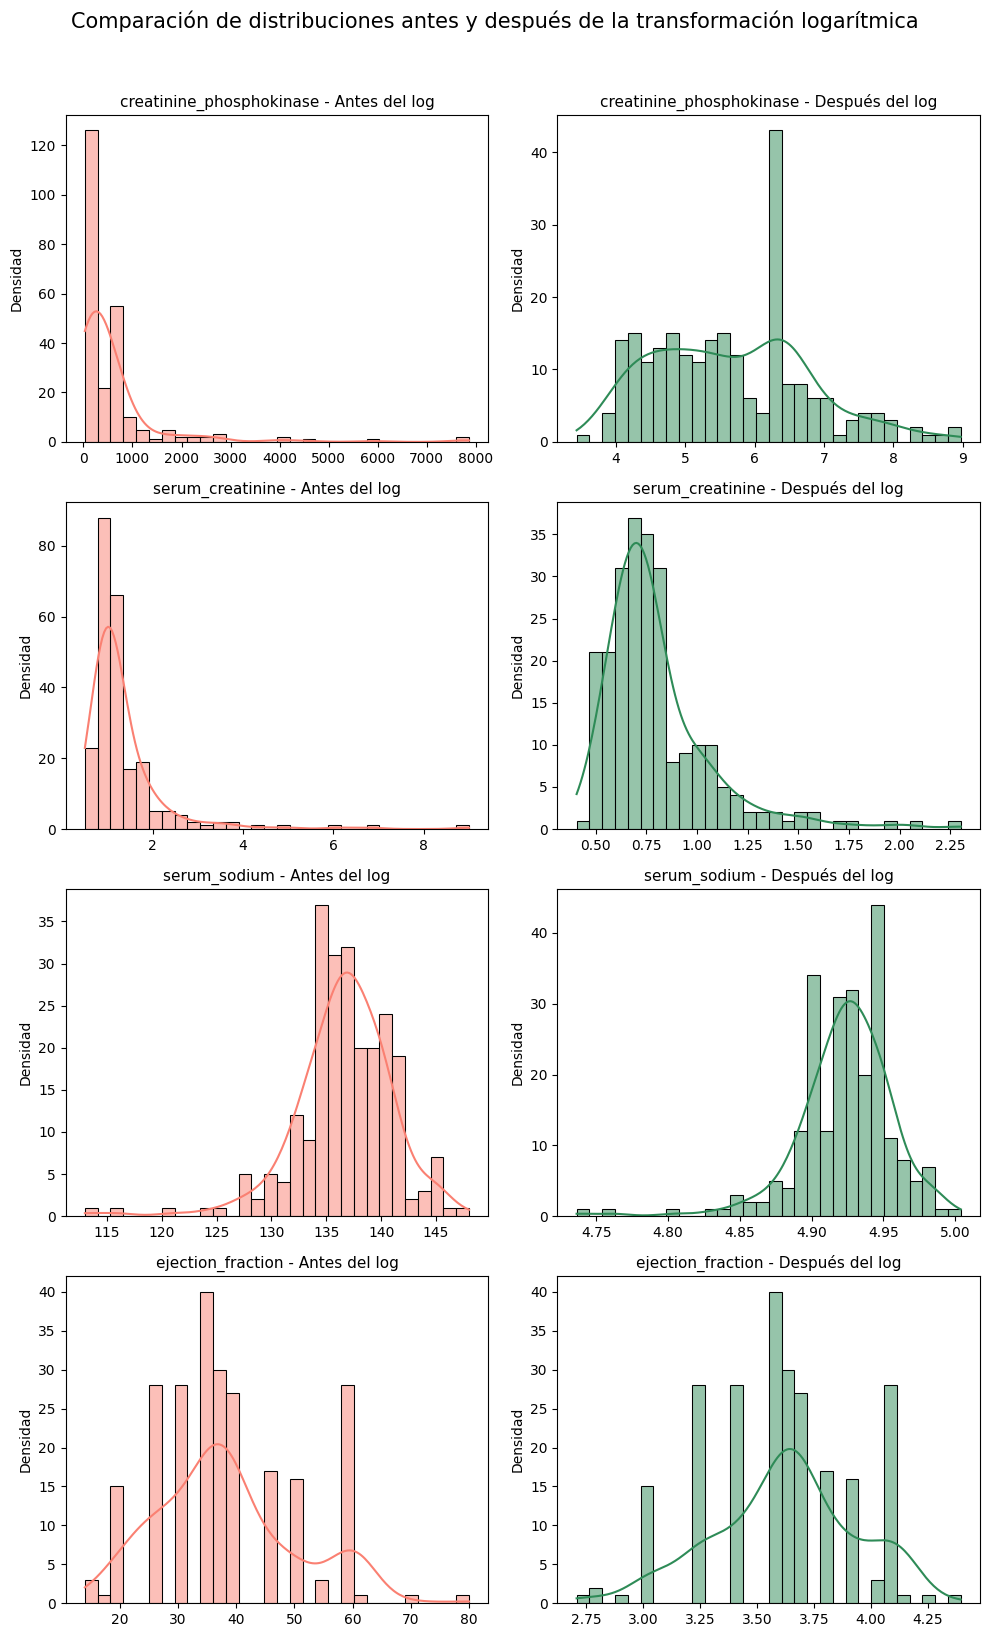

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables a comparar
variables = ["creatinine_phosphokinase", "serum_creatinine", 'serum_sodium', 'ejection_fraction']

# Crear figura: 4 filas (una por variable), 2 columnas (antes/después)
fig, axes = plt.subplots(nrows=len(variables), ncols=2, figsize=(10, 4 * len(variables)))

for i, var in enumerate(variables):
    # Columna izquierda → antes del log
    sns.histplot(x_train[var], bins=30, kde=True, ax=axes[i, 0], color='salmon')
    axes[i, 0].set_title(f'{var} - Antes del log', fontsize=11)
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Densidad')

    # Columna derecha → después del log (si existe la versión log)
    log_var = f"{var}_log"
    if log_var in x_train.columns:
        sns.histplot(x_train[log_var], bins=30, kde=True, ax=axes[i, 1], color='seagreen')
        axes[i, 1].set_title(f'{var} - Después del log', fontsize=11)
        axes[i, 1].set_xlabel('')
        axes[i, 1].set_ylabel('Densidad')
    else:
        # Si no hay columna log, dejar celda vacía
        axes[i, 1].axis('off')

plt.suptitle("Comparación de distribuciones antes y después de la transformación logarítmica",
             y=1.02, fontsize=15)
plt.tight_layout()
plt.show()


Número de outliers detectados por variable:


,Outliers,%_sobre_total
serum_creatinine_log,16.0,6.69
platelets,16.0,6.69
serum_sodium_log,6.0,2.51
ejection_fraction_log,3.0,1.26
creatinine_phosphokinase_log,2.0,0.84
age,2.0,0.84
anaemia,0.0,0.00
diabetes,0.0,0.00
high_blood_pressure,0.0,0.00
time,0.0,0.00


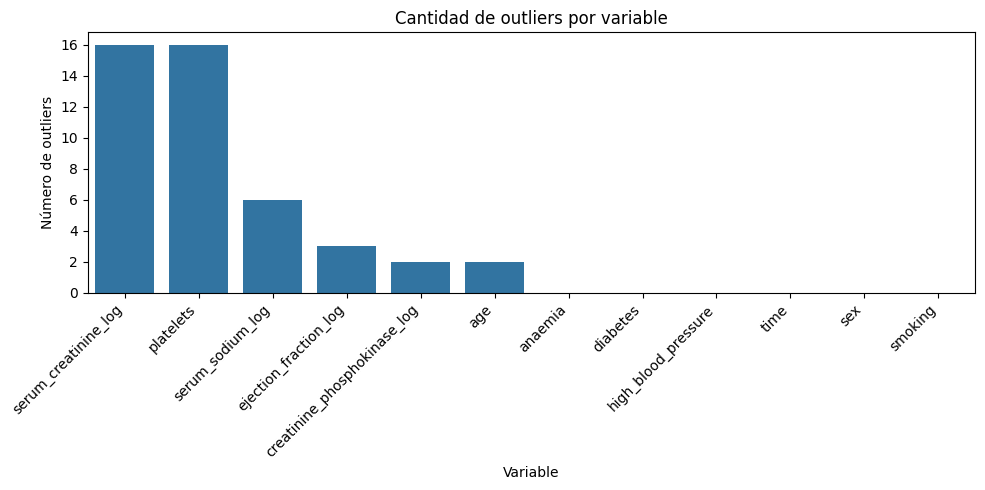

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols_limpio = x_train_limpio.select_dtypes(include=['int64', 'float64']).columns

outlier_counts = {}
total_n = len(x_train_limpio)

for col in numeric_cols_limpio:
    series = x_train_limpio[col].dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (x_train_limpio[col] < lower) | (x_train_limpio[col] > upper)
    outlier_counts[col] = {
        'Outliers': int(mask.sum()),
        '%_sobre_total': round(100.0 * mask.sum() / total_n, 2)
    }

outlier_df = pd.DataFrame(outlier_counts).T.sort_values(by='Outliers', ascending=False)
print("Número de outliers detectados por variable:")
display(outlier_df)

# Gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=outlier_df.index, y=outlier_df['Outliers'])
plt.title("Cantidad de outliers por variable")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Número de outliers")
plt.xlabel("Variable")
plt.tight_layout()
plt.show()


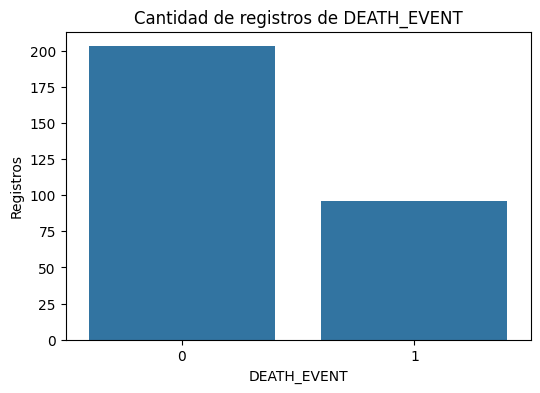

La proporción de registros es:  DEATH_EVENT
0    0.67893
1    0.32107
Name: proportion, dtype: float64


In [99]:
# Generamos un gráfico para comparar registros
plt.figure(figsize=(6, 4))
sns.countplot(x="DEATH_EVENT", data=dataset)
plt.xlabel("DEATH_EVENT")
plt.ylabel("Registros")
plt.title("Cantidad de registros de DEATH_EVENT")
plt.show()

# Calculamos la proporción de valores
print("La proporción de registros es: ", dataset['DEATH_EVENT'].value_counts(normalize=True))

In [100]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.fit(x_train_limpio)
x_train_limpio_s = scaler.transform(x_train_limpio)
x_test_limpio_s = scaler.transform(x_test_limpio)

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train_limpio)
x_train_limpio_ss = scaler.transform(x_train_limpio)
x_test_limpio_ss = scaler.transform(x_test_limpio)

In [102]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(x_train_limpio)
x_train_limpio_sm = scaler.transform(x_train_limpio)
x_test_limpio_sm = scaler.transform(x_test_limpio)

# Predicciones y evaluaciones sobre Train-Test

In [69]:
# Dataset aproximación log a variables propensas a outliers (KFold + RandomSearchCV)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold, train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Modelo base
clf = RandomForestClassifier(random_state=173869890, class_weight='balanced')

# Espacio de hiperparámetros para búsqueda aleatoria

param_grid = {
    "n_estimators": [74, 80, 86],
    "max_features": ['sqrt', 'log2'],         # int o 'sqrt'/'log2'
    "max_depth": [2, 4, 6, None],
    "min_samples_split":  [42, 47, 52],
    "min_samples_leaf": [18, 20, 22],
    "bootstrap": [True, False]
}

# Configurar validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=173869890)

# Randomized Search
random_clf = RandomizedSearchCV(
    estimator=clf,
    param_distributions = param_grid,
    n_iter=100,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=173869890,
    refit=True
)

# Entrenamiento
random_clf.fit(x_train_limpio, y_train)

# Evaluación
best_model = random_clf.best_estimator_
y_pred = best_model.predict(x_test_limpio)
y_proba = best_model.predict_proba(x_test_limpio)[:, 1]

print("Mejores hiperparámetros:", random_clf.best_params_)
print("AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=6))

Mejores hiperparámetros: {'n_estimators': 80, 'min_samples_split': 52, 'min_samples_leaf': 18, 'max_features': 'log2', 'max_depth': 2, 'bootstrap': True}
AUC: 0.9225113122171946
              precision    recall  f1-score   support

           0   0.864865  0.941176  0.901408        34
           1   0.913043  0.807692  0.857143        26

    accuracy                       0.883333        60
   macro avg   0.888954  0.874434  0.879276        60
weighted avg   0.885742  0.883333  0.882227        60



In [105]:
# Dataset aproximación log a variables propensas a outliers (KFold + GridSearchCV)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import classification_report, roc_auc_score

clf = RandomForestClassifier(random_state=173869890, class_weight='balanced')

param_grid = {
    "n_estimators": [70, 74, 80],
    "max_features": ['sqrt'],
    "max_depth": [None, 2, 4],
    "min_samples_split":  [42, 47],
    "min_samples_leaf": [18, 20],
    "bootstrap": [True]
}

cv = KFold(n_splits=5, shuffle=True, random_state=173869890)

grid_clf = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)

grid_clf.fit(x_train_limpio, y_train)

best_model = grid_clf.best_estimator_
y_pred = best_model.predict(x_test_limpio)
y_proba = best_model.predict_proba(x_test_limpio)[:, 1]

print("Mejores hiperparámetros:", grid_clf.best_params_)
print("AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=6))


Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'min_samples_split': 47, 'n_estimators': 80}
AUC: 0.9570135746606335
              precision    recall  f1-score   support

           0   0.966667  0.852941  0.906250        34
           1   0.833333  0.961538  0.892857        26

    accuracy                       0.900000        60
   macro avg   0.900000  0.907240  0.899554        60
weighted avg   0.908889  0.900000  0.900446        60



In [108]:
# Dataset aproximación log a variables propensas a outliers (StratifiedKFold + GridSearchCV)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score

clf = RandomForestClassifier(random_state=173869890, class_weight='balanced')

param_grid = {
    "n_estimators": [70, 74, 80],
    "max_features": ['sqrt'],
    "max_depth": [None, 2, 4],
    "min_samples_split":  [42, 47],
    "min_samples_leaf": [18, 20],
    "bootstrap": [True]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=173869890)

grid_clf = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)

grid_clf.fit(x_train_limpio, y_train)

best_model = grid_clf.best_estimator_
y_pred = best_model.predict(x_test_limpio)
y_proba = best_model.predict_proba(x_test_limpio)[:, 1]

print("Mejores hiperparámetros:", grid_clf.best_params_)
print("AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=6))


Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 18, 'min_samples_split': 42, 'n_estimators': 70}
AUC: 0.9581447963800905
              precision    recall  f1-score   support

           0   0.967742  0.882353  0.923077        34
           1   0.862069  0.961538  0.909091        26

    accuracy                       0.916667        60
   macro avg   0.914905  0.921946  0.916084        60
weighted avg   0.921950  0.916667  0.917016        60



In [110]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[30,  4],
       [ 1, 25]])

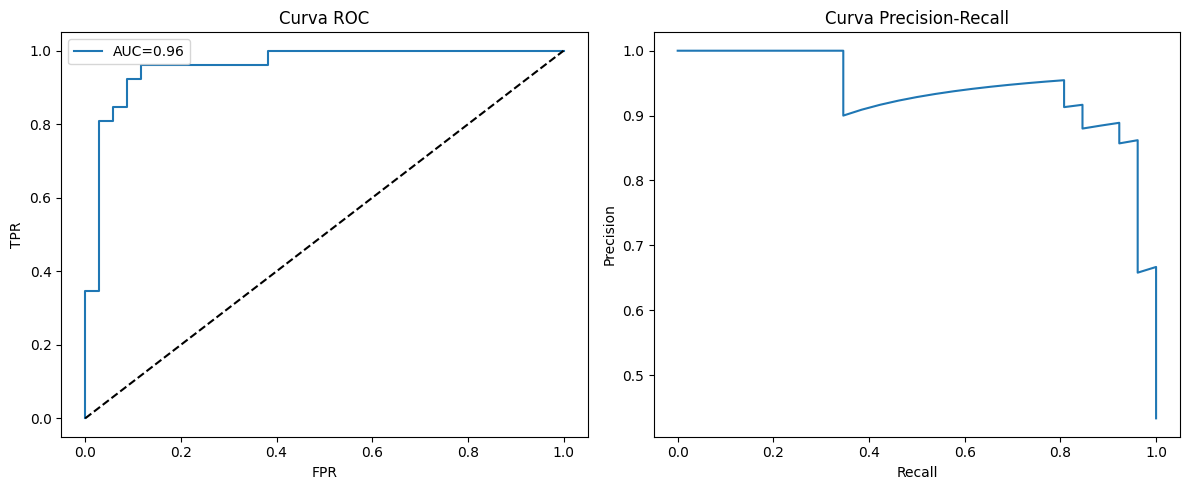

In [115]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_test_enc = le.fit_transform(y_test)

fpr, tpr, _ = roc_curve(y_test_enc, y_proba, pos_label=1)
precision, recall, _ = precision_recall_curve(y_test_enc, y_proba)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.2f}")
plt.plot([0,1],[0,1],'k--')
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision)
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.tight_layout()
plt.show()